In [ ]:
import os
import sys
from pathlib import Path

ROOT = Path().resolve()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

ROOT: /home/jay/dev/document-type-classification-cv-2


In [ ]:
# import os
# print(os.getcwd())
print("hello")

In [2]:
import random
from typing import cast

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.dataset.transforms import build_train_transforms
from src.dataset.loader import build_train_valid_loaders

/home/jay/miniconda3/envs/cv_comp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
cfg = load_config(
    base_path=ROOT / "configs/base.yaml",
    data_path=ROOT / "experiments/template/configs/data.yaml",
    train_path=ROOT / "experiments/template/configs/train.yaml",
    inference_path=ROOT / "experiments/template/configs/inference.yaml",
    model_path=ROOT / "experiments/template/configs/model.yaml",
)

print(cfg)

namespace(project=namespace(name='document-type-classification', task='multiclass-image-classification', seed=42, num_classes=17, class_names=None), paths=namespace(data_dir='data', raw_dir='data/raw', processed_dir='data/processed', split_dir='data/split', train_csv='data/raw/train.csv', test_csv='data/raw/test.csv', sample_submission_csv='data/raw/sample_submission.csv', train_image_dir='data/raw/train', test_image_dir='data/raw/test', output_dir='outputs', checkpoint_dir='outputs/checkpoints', log_dir='outputs/logs', submission_dir='outputs/submissions'), runtime=namespace(device='auto', amp=True, compile=False, benchmark=False, deterministic=False), logging=namespace(use_wandb=True, wandb_project='document-type-classification', wandb_entity=None, log_interval=50, save_best_only=True, verbose=True), data=namespace(image_col='ID', label_col='target', num_workers=0, pin_memory=False, persistent_workers=False), image=namespace(size=224, channels=3, mean=[0.485, 0.456, 0.406], std=[0.22

In [4]:
train_df = pd.read_csv(ROOT / cfg.paths.train_csv)

print("shape:", train_df.shape)
train_df.head()

shape: (1570, 2)


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


target
0     100
1      46
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13     74
14     50
15    100
16    100
Name: count, dtype: int64
# of Train Data: 1570개


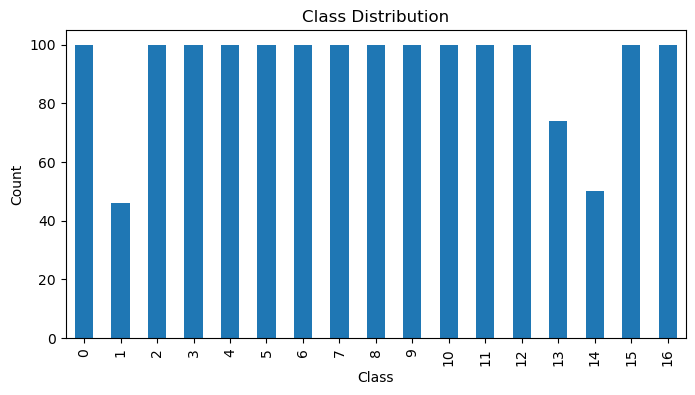

In [12]:
label_col = cfg.data.label_col

value_counts = train_df[label_col].value_counts().sort_index()

print(value_counts)
print(f"# of Train Data: {len(train_df)}개")

plt.figure(figsize=(8, 4))
value_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

image_name: 627c7ab37338a80a.jpg
image_path: data/raw/train/627c7ab37338a80a.jpg


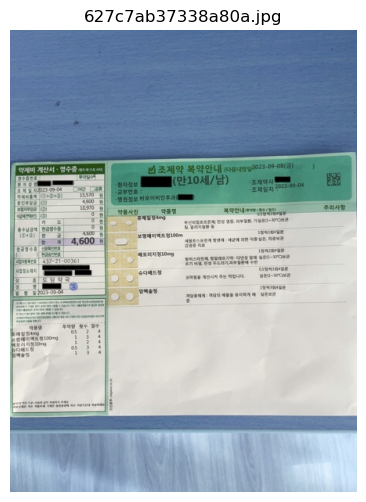

In [6]:
image_col = cfg.data.image_col

image_name = random.choice(train_df[image_col].tolist())
image_path = Path(cfg.paths.train_image_dir) / image_name

print("image_name:", image_name)
print("image_path:", image_path)

raw_image = cv2.imread(str(image_path))
if raw_image is None:
    raise ValueError(f"Failed to load image: {image_path}")

image = cast(np.ndarray, raw_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(image_name)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


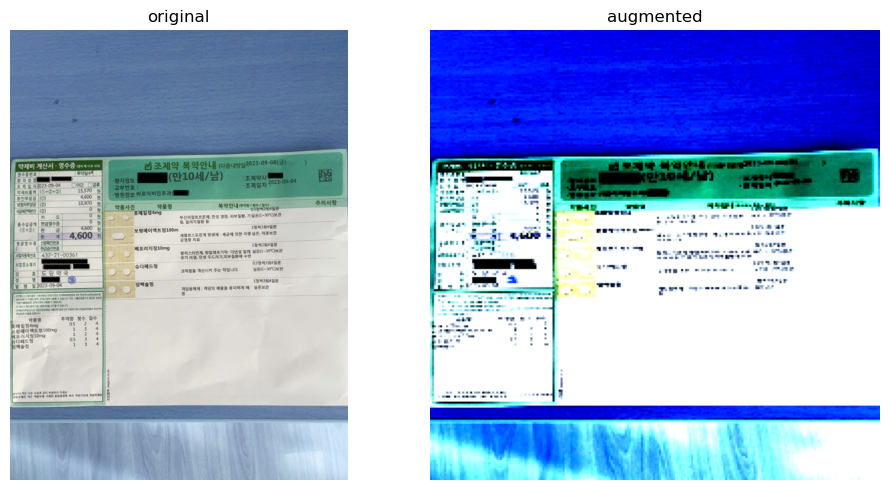

In [7]:
transform = build_train_transforms(cfg)

aug = transform(image=image)["image"].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aug)
plt.title("augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
train_loader, valid_loader = build_train_valid_loaders(cfg)

print("train loader ready")
print("valid loader ready")

train loader ready
valid loader ready


In [9]:
# batch shape 및 label 확인

batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("labels:", labels[:10])

images shape: torch.Size([4, 3, 224, 224])
labels shape: torch.Size([4])
labels: tensor([ 8, 14,  3, 13])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].


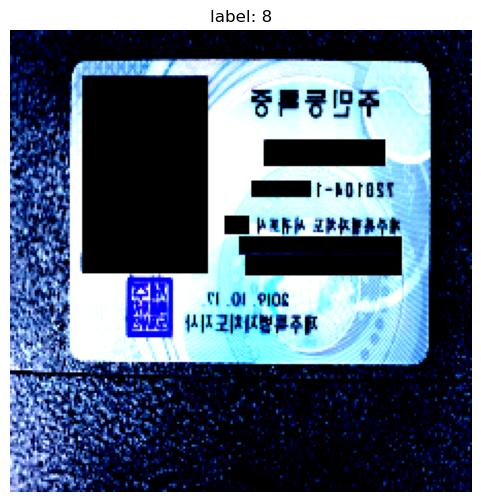

In [10]:
# batch image 1장 확인용

img = images[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"label: {labels[0].item()}")
plt.axis("off")
plt.show()